In [1]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

print(df.head())
print("\n")
print(df.columns.tolist())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [2]:
import pandas as pd

total_customers = len(df)

churned = df['Exited'].sum()

retained = total_customers - churned

churn_rate = round(churned/total_customers*100,2)

avg_balance = round(df['Balance'].mean(),2)

avg_salary = round(df['EstimatedSalary'].mean(),2)

print("="*50)
print("EXECUTIVE SUMMARY")
print("="*50)

print(f"Total Customers      : {total_customers:,}")
print(f"Retained Customers   : {retained:,}")
print(f"Churned Customers    : {churned:,}")
print(f"Churn Rate           : {churn_rate}%")
print(f"Average Balance      : ₹{avg_balance:,.2f}")
print(f"Average Salary       : ₹{avg_salary:,.2f}")

EXECUTIVE SUMMARY
Total Customers      : 10,000
Retained Customers   : 7,963
Churned Customers    : 2,037
Churn Rate           : 20.37%
Average Balance      : ₹76,485.89
Average Salary       : ₹100,090.24


In [3]:
geo = df.groupby('Geography').agg(
    customers=('CustomerId','count'),
    churned=('Exited','sum')
)

geo['churn_rate'] = round(
    geo['churned']/geo['customers']*100,
    2
)

geo.sort_values(
    by='churn_rate',
    ascending=False,
    inplace=True
)

geo

,customers,churned,churn_rate
Geography,,,
Germany,2509,814,32.44
Spain,2477,413,16.67
France,5014,810,16.15


In [4]:
gender = df.groupby('Gender').agg(
    customers=('CustomerId','count'),
    churned=('Exited','sum')
)

gender['churn_rate'] = round(
    gender['churned']/gender['customers']*100,
    2
)

gender

,customers,churned,churn_rate
Gender,,,
Female,4543,1139,25.07
Male,5457,898,16.46


In [5]:
products = df.groupby('NumOfProducts').agg(
    customers=('CustomerId','count'),
    churned=('Exited','sum')
)

products['churn_rate'] = round(
    products['churned']/products['customers']*100,
    2
)

products

,customers,churned,churn_rate
NumOfProducts,,,
1,5084,1409,27.71
2,4590,348,7.58
3,266,220,82.71
4,60,60,100.00


In [6]:
active = df.groupby('IsActiveMember').agg(
    customers=('CustomerId','count'),
    churned=('Exited','sum')
)

active['churn_rate'] = round(
    active['churned']/active['customers']*100,
    2
)

active

,customers,churned,churn_rate
IsActiveMember,,,
0,4849,1302,26.85
1,5151,735,14.27


In [7]:
import sqlite3

conn = sqlite3.connect("customer_churn.db")

df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Database created")

Database created


In [8]:
query = """
SELECT
Geography,
COUNT(*) as customers,
SUM(Exited) as churned,
ROUND(
SUM(Exited)*100.0/COUNT(*),
2
) as churn_rate
FROM customers
GROUP BY Geography
ORDER BY churn_rate DESC
"""

pd.read_sql(query, conn)

,Geography,customers,churned,churn_rate
0,Germany,2509,814,32.44
1,Spain,2477,413,16.67
2,France,5014,810,16.15


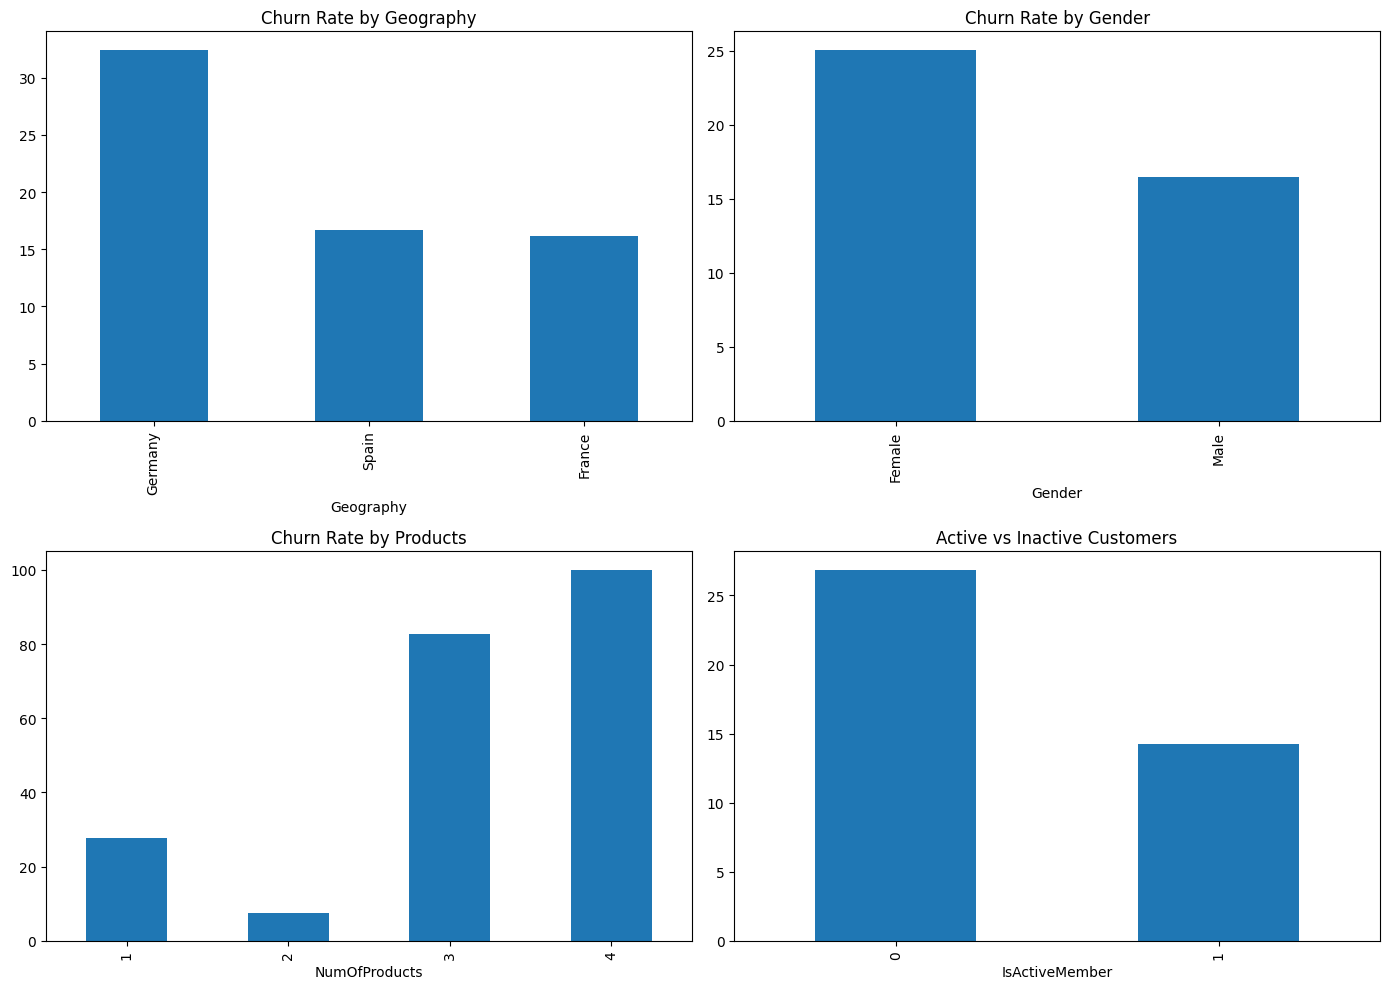

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# Geography

geo['churn_rate'].plot(
    kind='bar',
    ax=axes[0,0]
)

axes[0,0].set_title("Churn Rate by Geography")

# Gender

gender['churn_rate'].plot(
    kind='bar',
    ax=axes[0,1]
)

axes[0,1].set_title("Churn Rate by Gender")

# Products

products['churn_rate'].plot(
    kind='bar',
    ax=axes[1,0]
)

axes[1,0].set_title("Churn Rate by Products")

# Active Members

active['churn_rate'].plot(
    kind='bar',
    ax=axes[1,1]
)

axes[1,1].set_title("Active vs Inactive Customers")

plt.tight_layout()

plt.savefig(
    "customer_churn_dashboard.png",
    dpi=300
)

plt.show()

In [10]:
print("""
BUSINESS INSIGHTS

1. Identify geography with highest churn risk.

2. Inactive customers churn significantly more.

3. Product ownership strongly impacts retention.

4. Target high-risk customer segments with
   retention campaigns.

5. Increase engagement among inactive users.

6. Build loyalty programs for customers with
   high balances and multiple products.
""")


BUSINESS INSIGHTS

1. Identify geography with highest churn risk.

2. Inactive customers churn significantly more.

3. Product ownership strongly impacts retention.

4. Target high-risk customer segments with
   retention campaigns.

5. Increase engagement among inactive users.

6. Build loyalty programs for customers with
   high balances and multiple products.

